In [67]:
import matplotlib.pyplot as plt
import pandas as pd
import json
import numpy as np
import seaborn as sns

In [68]:


# Local file path - no need for Google Drive mounting
filghts_path = 'data/All flights - data.csv'

# Load data from CSV
data = pd.read_csv(filghts_path, index_col=False)
df = pd.DataFrame(data)

In [69]:
df.head()


,Operation time,Airline,Flight Num,Departure Airport,Arrival Airport,Terminal,Departure / Arrival,Origin Date,CodeContext
0,2021-12-29 16:49:00,AH,1011,ORY,ALG,4,Arrival,2021-12-29,ONB
1,2021-12-29 18:30:00,AH,2014,ALG,BCN,4,Departure,2021-12-29,OFB
2,2021-12-29 12:09:00,LH,1316,FRA,ALG,4,Arrival,2021-12-29,ONB
3,2021-12-29 13:25:00,LH,1317,ALG,FRA,4,Departure,2021-12-29,OFB
4,2021-12-29 10:03:00,5O,1051,CDG,ALG,4,Arrival,2021-12-29,ONB


In [70]:
df.tail()

,Operation time,Airline,Flight Num,Departure Airport,Arrival Airport,Terminal,Departure / Arrival,Origin Date,CodeContext
157713,2024-12-05 8:00:00,SF,3018,ALG,SXB,4,Departure,2024-12-05,SCT
157714,2024-12-05 9:00:00,SF,1850,ALG,CBH,1,Departure,2024-12-05,SCT
157715,2024-12-05 18:15:00,SF,1802,ALG,HME,1,Departure,2024-12-05,SCT
157716,2024-12-05 14:00:00,SF,1844,ALG,CZL,1,Departure,2024-12-05,SCT
157717,2024-12-05 8:40:00,SF,1848,ALG,BSK,1,Departure,2024-12-05,SCT


# 1.Data Cleaning

In [71]:
# Rename columns to remove spaces and make them lowercase
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '')

# Now convert to datetime
df['operationtime'] = pd.to_datetime(df['operationtime'], errors='coerce')
df['origindate']    = pd.to_datetime(df['origindate'],    errors='coerce')

In [72]:
str_cols = ['airline', 'departureairport', 'arrivalairport', 'codecontext']

for col in str_cols:
    df[col] = df[col].astype(str).str.strip().str.upper()
    df[col] = df[col].replace('', pd.NA).replace('NAN', pd.NA)

In [73]:
key_cols = ['flightnum', 'operationtime', 'origindate','departureairport', 'arrivalairport', 'codecontext']
df['missing_key_count'] = df[key_cols].isna().sum(axis=1)

In [74]:
df_clean = df[df['missing_key_count'] <= 1].copy()

In [75]:
mask_bad_fn = df_clean['flightnum'].isna()
mask_bad_ap = df_clean['departureairport'].isna() & df_clean['arrivalairport'].isna()
df_clean = df_clean[~(mask_bad_fn | mask_bad_ap)].copy()

In [76]:
df_clean = df_clean.drop(columns=['missing_key_count'])

In [77]:
df_clean.to_csv('data/airport_data_clean.csv', index=False)

In [78]:
print(df_clean.info())
print('-----------------------------------------------------')
print(df_clean.isna().sum())
print('-----------------------------------------------------')
print(df_clean[['airline', 'departureairport', 'arrivalairport', 'codecontext']].head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157718 entries, 0 to 157717
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   operationtime      157718 non-null  datetime64[ns]
 1   airline            157718 non-null  object        
 2   flightnum          157718 non-null  object        
 3   departureairport   157718 non-null  object        
 4   arrivalairport     157718 non-null  object        
 5   terminal           157718 non-null  object        
 6   departure/arrival  157718 non-null  object        
 7   origindate         157718 non-null  datetime64[ns]
 8   codecontext        157718 non-null  object        
dtypes: datetime64[ns](2), object(7)
memory usage: 10.8+ MB
None
-----------------------------------------------------
operationtime        0
airline              0
flightnum            0
departureairport     0
arrivalairport       0
terminal             0
departure/arrival

In [79]:
# now we work with df_clean

In [80]:
#Create new column For status_text (map codeContext => status_text)
# Create new column For status_text (map codecontext => status_text)
if "status_map" not in globals():
    status_map = {
        "SCT": "Scheduled_OnTime",
        "EAR": "Scheduled_OnTime",
        "DEL": "Delayed",
        "BST": "Boarding",
        "BEN": "Boarding",
        "GCL": "Boarding",
        "FCL": "Boarding",
        "OFB": "Departed",
        "THM": "EnRoute",
        "TEN": "EnRoute",
        "LAN": "Arrived",
        "ONB": "Arrived",
        "DX": "Cancelled",
        "DV": "Diverted",
        "RT": "Diverted",
        "GRT": "Diverted",
    }

df_clean["status_text"] = df_clean["codecontext"].map(status_map)

df_clean.head()

df_clean.head()

,operationtime,airline,flightnum,departureairport,arrivalairport,terminal,departure/arrival,origindate,codecontext,status_text
0,2021-12-29 16:49:00,AH,1011,ORY,ALG,4,Arrival,2021-12-29,ONB,Arrived
1,2021-12-29 18:30:00,AH,2014,ALG,BCN,4,Departure,2021-12-29,OFB,Departed
2,2021-12-29 12:09:00,LH,1316,FRA,ALG,4,Arrival,2021-12-29,ONB,Arrived
3,2021-12-29 13:25:00,LH,1317,ALG,FRA,4,Departure,2021-12-29,OFB,Departed
4,2021-12-29 10:03:00,5O,1051,CDG,ALG,4,Arrival,2021-12-29,ONB,Arrived


In [81]:
#check if mapping was not done somewhere
df_clean['status_text'].isna().sum()

np.int64(0)

In [82]:
#Display values/counts per feature to detect noise / outliers
terminal_counts = df_clean['terminal'].value_counts(dropna=False)
print(terminal_counts)


terminal
4    78932
1    75577
0     1573
2     1201
3      267
W      124
F       31
O        5
w        4
J        2
j        1
.        1
Name: count, dtype: int64


In [83]:
airline_counts = df_clean['airline'].value_counts(dropna=False)
print(airline_counts)
#2-letter codes are used

airline
AH     100392
SF      17074
AF       7816
TO       5927
5O       4087
TK       3769
VY       2417
TU       1947
AZ       1843
MS       1701
SV       1688
LH       1572
QR       1333
EK       1316
BA       1213
V7        894
XY        591
IB        552
BJ        546
TB        407
AC        258
RJ        230
HU         34
TT         17
VF         14
UG         13
ZZ          9
ST          8
AP          7
8U          7
TP          6
HT          5
NI          4
LN          4
SM          3
KLJ         2
AN          2
IA          2
SA          2
AE          2
TLJ         2
AX          1
F6          1
Name: count, dtype: int64


In [84]:
status_counts = df_clean['status_text'].value_counts(dropna=False)
print(status_counts)

status_text
Arrived             65754
Departed            64140
Scheduled_OnTime    17639
Delayed              5634
Cancelled            3542
Boarding             1009
Name: count, dtype: int64


In [85]:

distinct_arrivalairports = df_clean['arrivalairport'].unique()
print(distinct_arrivalairports.size)
print(distinct_arrivalairports)

arrivalairport_counts = df_clean['arrivalairport'].value_counts(dropna=False)
print(arrivalairport_counts)

163
['ALG' 'BCN' 'FRA' 'CDG' 'TMR' 'DOH' 'IST' 'MPL' 'AAE' 'ORN' 'NTE' 'ORY'
 'CZL' 'LHR' 'YUL' 'LYS' 'BOD' 'TUN' 'FCO' 'DXB' 'HME' 'BSK' 'DJG' 'ELU'
 'GJL' 'TID' 'TEE' 'TMX' 'OGX' 'AZR' 'GHA' 'IAM' 'TLM' 'BJA' 'ELG' 'SVO'
 'TIN' 'TGR' 'LOO' 'CBH' 'EBH' 'VVZ' 'INZ' 'BLJ' 'MRS' 'RNS' 'HRM' 'MZW'
 'TEST' 'LIL' 'MAD' 'CTU' 'TFT' 'LIS' 'DEL' 'KBJ' 'BRU' 'DLA' 'BKO' 'CAI'
 'DAE' 'GVA' 'MJI' 'ALC' 'VGO' 'NDJ' 'FRW' 'OTP' 'CKY' 'NIM' 'SOF' 'SSG'
 'RHOUDE' 'DSS' 'VLC' 'NKC' 'KRECHBA' 'JED' 'CMN' 'RHOUD' 'TINFOUYET'
 'TLS' 'MXP' 'NCE' 'MED' 'AGP' 'SVQ' 'DJE' 'CRL' 'SXB' 'TIP' 'HGH' 'MLH'
 'QSF' 'AYT' 'ZRH' 'VIE' 'STN' 'PEK' 'ASW' 'SSH' 'BMW' 'MIR' 'BIO' 'VLL'
 'TFS' 'ROB' 'BGW' 'ABJ' 'OUA' 'AMM' 'LBV' 'BEY' 'LFW' 'FIH' 'TBJ' 'ETZ'
 'CCS' 'MUC' 'BUD' 'MMX' 'OVD' 'PNA' 'KAN' 'TOE' 'JNB' 'HRG' 'LAD' 'BEN'
 'BZV' 'ACC' 'LED' 'PMI' 'LGW' 'RUH' 'DAR' 'PHC' 'DAM' 'BGY' 'OUD' 'MJV'
 'RBA' 'AUH' 'VCE' 'EBB' 'BJL' 'ZAZ' 'LBG' 'TLN' 'CFK' 'QFD' 'BVA' 'CHR'
 'BYJ' 'OST' 'CEG' 'CIA' 'SAW' 'ADD' 'SBN' 'FBM' 

In [86]:
distinct_departureairport = df_clean['departureairport'].unique()
print(distinct_departureairport.size)
print(distinct_arrivalairports)

departureairport_counts = df_clean['departureairport'].value_counts(dropna=False)
print(departureairport_counts)

158
['ALG' 'BCN' 'FRA' 'CDG' 'TMR' 'DOH' 'IST' 'MPL' 'AAE' 'ORN' 'NTE' 'ORY'
 'CZL' 'LHR' 'YUL' 'LYS' 'BOD' 'TUN' 'FCO' 'DXB' 'HME' 'BSK' 'DJG' 'ELU'
 'GJL' 'TID' 'TEE' 'TMX' 'OGX' 'AZR' 'GHA' 'IAM' 'TLM' 'BJA' 'ELG' 'SVO'
 'TIN' 'TGR' 'LOO' 'CBH' 'EBH' 'VVZ' 'INZ' 'BLJ' 'MRS' 'RNS' 'HRM' 'MZW'
 'TEST' 'LIL' 'MAD' 'CTU' 'TFT' 'LIS' 'DEL' 'KBJ' 'BRU' 'DLA' 'BKO' 'CAI'
 'DAE' 'GVA' 'MJI' 'ALC' 'VGO' 'NDJ' 'FRW' 'OTP' 'CKY' 'NIM' 'SOF' 'SSG'
 'RHOUDE' 'DSS' 'VLC' 'NKC' 'KRECHBA' 'JED' 'CMN' 'RHOUD' 'TINFOUYET'
 'TLS' 'MXP' 'NCE' 'MED' 'AGP' 'SVQ' 'DJE' 'CRL' 'SXB' 'TIP' 'HGH' 'MLH'
 'QSF' 'AYT' 'ZRH' 'VIE' 'STN' 'PEK' 'ASW' 'SSH' 'BMW' 'MIR' 'BIO' 'VLL'
 'TFS' 'ROB' 'BGW' 'ABJ' 'OUA' 'AMM' 'LBV' 'BEY' 'LFW' 'FIH' 'TBJ' 'ETZ'
 'CCS' 'MUC' 'BUD' 'MMX' 'OVD' 'PNA' 'KAN' 'TOE' 'JNB' 'HRG' 'LAD' 'BEN'
 'BZV' 'ACC' 'LED' 'PMI' 'LGW' 'RUH' 'DAR' 'PHC' 'DAM' 'BGY' 'OUD' 'MJV'
 'RBA' 'AUH' 'VCE' 'EBB' 'BJL' 'ZAZ' 'LBG' 'TLN' 'CFK' 'QFD' 'BVA' 'CHR'
 'BYJ' 'OST' 'CEG' 'CIA' 'SAW' 'ADD' 'SBN' 'FBM' 

In [87]:
# rest of preprocessing steps ..........

In [88]:
# Visualization for the data :

In [89]:
df_clean['date']      = df_clean['operationtime'].dt.date
df_clean['hour']      = df_clean['operationtime'].dt.hour
df_clean['weekday']   = df_clean['operationtime'].dt.weekday  # 0=Mon
df_clean['is_weekend'] = df_clean['weekday'].isin([5, 6])


In [90]:
distinct_hours = df_clean['hour'].unique()
print(distinct_hours.size)
print(distinct_hours)

24
[16 18 12 13 10 11  8 14 15 22 20 19 17  9 21  7 23  6  0  3  4  5  1  2]


In [91]:
df_clean['hour'].head(25)

0     16
1     18
2     12
3     13
4     10
5     11
6      8
7     10
8     12
9     14
10    13
11    15
12    14
13    16
14    16
15    18
16    22
17    20
18    18
19    19
20    20
21    17
22     8
23     9
24     8
Name: hour, dtype: int32

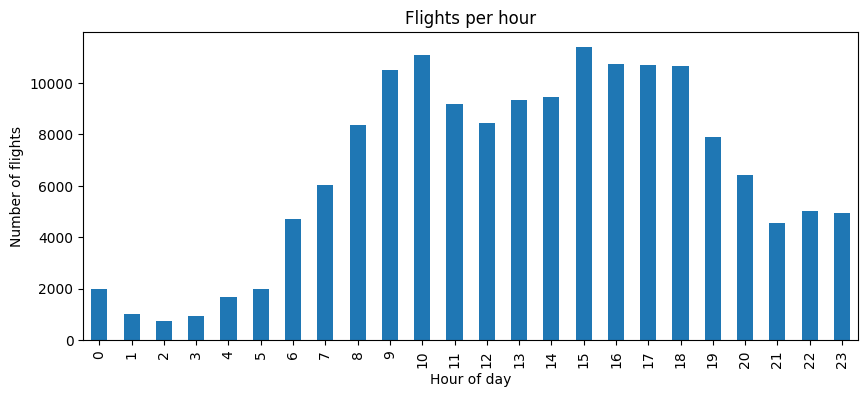

In [92]:


df_clean['hour'].value_counts().sort_index().plot(kind='bar', figsize=(10,4))
plt.xlabel('Hour of day'); plt.ylabel('Number of flights'); plt.title('Flights per hour')
plt.show()


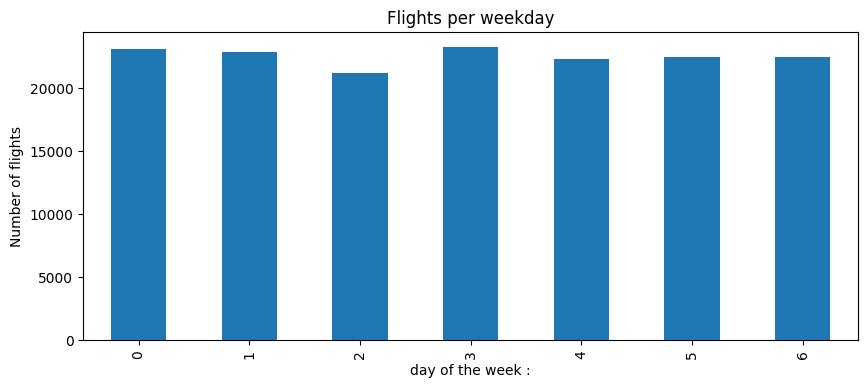

In [93]:
# 0 is monday
df_clean['weekday'].value_counts().sort_index().plot(kind='bar', figsize=(10,4))
plt.xlabel('day of the week :'); plt.ylabel('Number of flights'); plt.title('Flights per weekday')
plt.show()

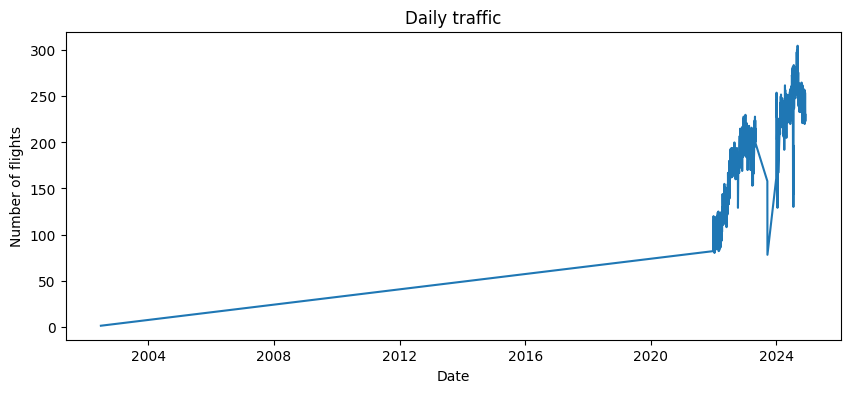

In [94]:
df_clean.groupby('date').size().plot(figsize=(10,4))
plt.xlabel('Date'); plt.ylabel('Number of flights'); plt.title('Daily traffic')
plt.show()


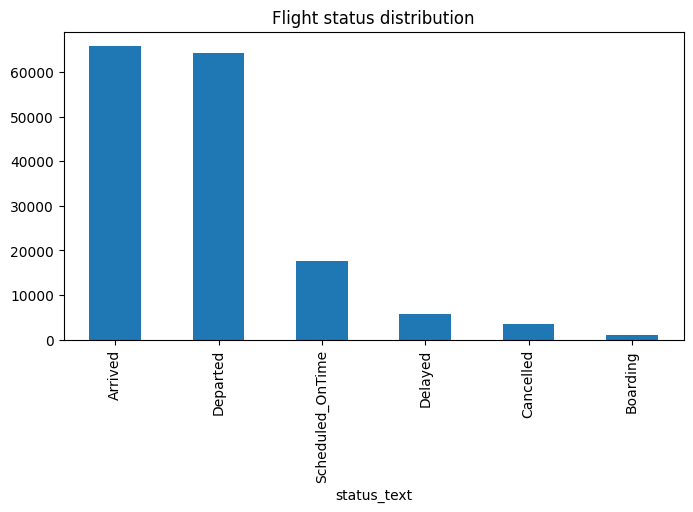

In [95]:
df_clean['status_text'].value_counts().plot(kind='bar', figsize=(8,4))
plt.title('Flight status distribution')
plt.show()
# we should check the status if they are repeated

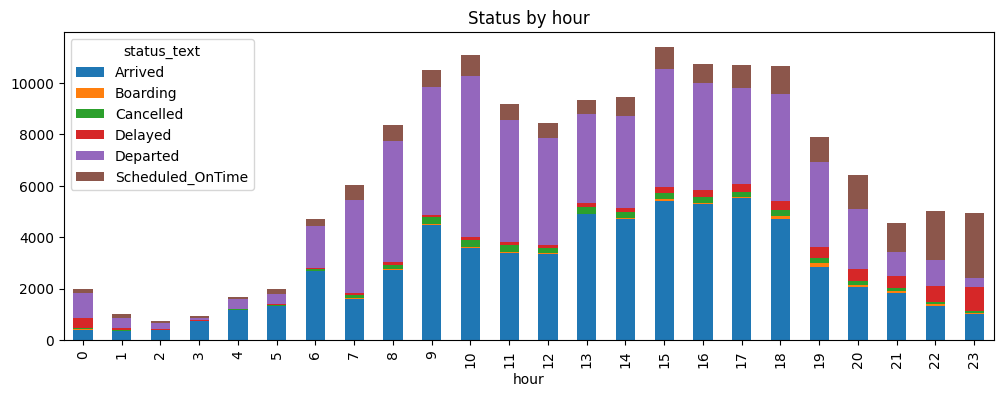

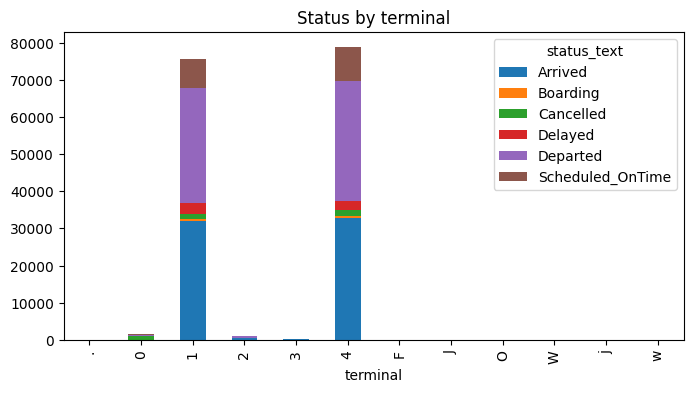

In [96]:
pd.crosstab(df_clean['hour'], df_clean['status_text']).plot(kind='bar', stacked=True, figsize=(12,4))
plt.title('Status by hour')
plt.show()

pd.crosstab(df_clean['terminal'], df_clean['status_text']).plot(kind='bar', stacked=True, figsize=(8,4))
plt.title('Status by terminal')
plt.show()


In [97]:
df_clean['route'] = df_clean['departureairport'] + '-' + df_clean['arrivalairport']

In [98]:
print(df_clean['route'].value_counts().head(10))
pd.crosstab(df_clean['route'], df_clean['status_text']).head(10)

route
ALG-CDG    7289
CDG-ALG    7258
ORY-ALG    5631
ALG-ORY    5629
CZL-ALG    4564
ALG-CZL    4551
ALG-ORN    4492
ORN-ALG    4475
HME-ALG    4004
ALG-IST    3728
Name: count, dtype: int64


status_text,Arrived,Boarding,Cancelled,Delayed,Departed,Scheduled_OnTime
route,,,,,,
AAE-ALG,2602,0,21,127,0,239
ABJ-ALG,162,0,4,0,0,19
ACC-ALG,2,0,0,1,0,2
ADD-ALG,0,0,1,0,0,1
AGP-ALG,9,0,0,1,0,0
ALC-ALG,197,0,1,15,0,35
ALG-AAE,0,39,26,57,2669,230
ALG-ABJ,0,0,7,16,116,39
ALG-ACC,0,0,1,0,3,2


In [99]:
df_clean.tail(10)

,operationtime,airline,flightnum,departureairport,arrivalairport,terminal,departure/arrival,origindate,codecontext,status_text,date,hour,weekday,is_weekend,route
157708,2024-12-05 10:45:00,TK,651,IST,ALG,4,Arrival,2024-12-05,SCT,Scheduled_OnTime,2024-12-05,10,3,False,IST-ALG
157709,2024-12-05 11:40:00,TK,652,ALG,IST,4,Departure,2024-12-05,SCT,Scheduled_OnTime,2024-12-05,11,3,False,ALG-IST
157710,2024-12-05 09:30:00,SF,1974,ALG,BJA,1,Departure,2024-12-05,SCT,Scheduled_OnTime,2024-12-05,9,3,False,ALG-BJA
157711,2024-12-05 14:30:00,SF,2112,ALG,CZL,1,Departure,2024-12-05,SCT,Scheduled_OnTime,2024-12-05,14,3,False,ALG-CZL
157712,2024-12-05 15:45:00,SF,1810,ALG,ORN,1,Departure,2024-12-05,SCT,Scheduled_OnTime,2024-12-05,15,3,False,ALG-ORN
157713,2024-12-05 08:00:00,SF,3018,ALG,SXB,4,Departure,2024-12-05,SCT,Scheduled_OnTime,2024-12-05,8,3,False,ALG-SXB
157714,2024-12-05 09:00:00,SF,1850,ALG,CBH,1,Departure,2024-12-05,SCT,Scheduled_OnTime,2024-12-05,9,3,False,ALG-CBH
157715,2024-12-05 18:15:00,SF,1802,ALG,HME,1,Departure,2024-12-05,SCT,Scheduled_OnTime,2024-12-05,18,3,False,ALG-HME
157716,2024-12-05 14:00:00,SF,1844,ALG,CZL,1,Departure,2024-12-05,SCT,Scheduled_OnTime,2024-12-05,14,3,False,ALG-CZL
157717,2024-12-05 08:40:00,SF,1848,ALG,BSK,1,Departure,2024-12-05,SCT,Scheduled_OnTime,2024-12-05,8,3,False,ALG-BSK


In [100]:
#Outliers handling ...

In [101]:
#Terminal:
terminals_list = df['terminal'].astype(str).unique().tolist()
print(terminals_list)
valid_terminals = ['1', '2', '4']
invalid_values = [x for x in terminals_list if x not in valid_terminals]
print(invalid_values)

['4', '1', '0', 'W', '2', '3', 'w', 'O', 'F', 'j', 'J', '.']
['0', 'W', '3', 'w', 'O', 'F', 'j', 'J', '.']


In [102]:
#Visualization of terminals => Hajj / Omra
#filter flights where departure OR arrival is MED or JED
airports_of_interest = ['MED', 'JED']
filtered_df = df_clean[
    (df_clean['departureairport'].isin(airports_of_interest)) |
    (df_clean['arrivalairport'].isin(airports_of_interest))
]

terminal_counts = filtered_df['terminal'].value_counts()
print(terminal_counts)


terminal
1    1695
2    1153
4     712
3     265
0     115
F       5
W       1
O       1
j       1
Name: count, dtype: int64


In [103]:
terminals = ['0', '3']
filtered_df = df_clean[
    (df_clean['terminal'].isin(terminals))
]
terminal_counts = filtered_df['route'].value_counts()
filtered_df.head(10)
print(terminal_counts)


route
ALG-CDG    133
CDG-ALG    124
JED-ALG    115
ALG-JED    101
ALG-MED     84
          ... 
VVZ-ALG      1
ALG-TOE      1
ALG-KWI      1
COO-ALG      1
SAW-ALG      1
Name: count, Length: 212, dtype: int64


In [104]:
routes = ['MED-ALG','JED-ALG']
filtered_df = df_clean[
    (df_clean['route'].isin(routes))
]
terminal_counts = filtered_df['terminal'].value_counts()
filtered_df.head(10)
print(terminal_counts)


terminal
1    822
2    588
4    345
3    144
0     51
F      5
O      1
j      1
Name: count, dtype: int64


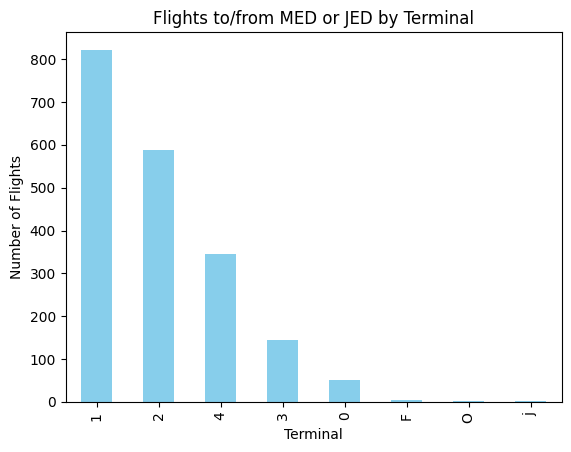

In [105]:


terminal_counts.plot(kind='bar', color='skyblue')
plt.title('Flights to/from MED or JED by Terminal')
plt.xlabel('Terminal')
plt.ylabel('Number of Flights')
plt.show()

In [106]:
#Only for non hajj / omra
#Replace invalid terminal with valid terminal depending on simialr instances in terms of arrivalairport and departure airport
for idx, row in df_clean[df_clean['terminal'].isin(invalid_values)].iterrows():

    #Skip Hajj / Omra routes (ambiguous terminals)
    if (
        (not(row['departureairport'] in ['MED', 'JED'])) and
        (not(row['arrivalairport'] in ['MED', 'JED']))
    ):
      #find similar flights
      similar = df_clean[
          (df_clean['departureairport'] == row['departureairport']) &
          (df_clean['arrivalairport'] == row['arrivalairport']) &
          (~df_clean['terminal'].isin(invalid_values))
      ]

      #replace invalid by valid
      if not similar.empty:
          df_clean.at[idx, 'terminal'] = similar['terminal'].mode()[0]


In [107]:
remaining_invalid = df_clean[
    (~df_clean['terminal'].isin(valid_terminals)) &
    (~df_clean['departureairport'].isin(['MED', 'JED'])) &
    (~df_clean['arrivalairport'].isin(['MED', 'JED']))
]

print("Remaining invalid terminals (non-Hajj/Omra):", len(remaining_invalid))
#could not be handled by previous algorithm

Remaining invalid terminals (non-Hajj/Omra): 18


In [108]:
#All assign terminal 4 (they are all international)
df_clean.loc[remaining_invalid.index, 'terminal'] = '4'


In [109]:
check = df_clean[
    (~df_clean['terminal'].isin(valid_terminals)) &
    (~df_clean['departureairport'].isin(['MED', 'JED'])) &
    (~df_clean['arrivalairport'].isin(['MED', 'JED']))
]
print("Remaining invalid terminals (non-Hajj/Omra) CHECK:", len(check))
#could not be handled by previous algorithm

Remaining invalid terminals (non-Hajj/Omra) CHECK: 0


In [110]:
#------------------------------------------------------
#All terminal outliers handled except for MED / JED ...
#------------------------------------------------------

In [111]:
routes = ['MED-ALG','JED-ALG','ALG-JED','ALG-MED']
HajjUmrah = df_clean[(df_clean['route'].isin(routes))]
valid_terminals = ['1', '2', '4']
route_noise = df_clean[~df_clean['terminal'].isin(valid_terminals)]

In [112]:
route_noise.head()

,operationtime,airline,flightnum,departureairport,arrivalairport,terminal,departure/arrival,origindate,codecontext,status_text,date,hour,weekday,is_weekend,route
9301,2022-03-28 14:05:00,SV,341,JED,ALG,0,Arrival,2022-03-28,DX,Cancelled,2022-03-28,14,0,False,JED-ALG
9302,2022-03-28 16:25:00,SV,340,ALG,JED,0,Departure,2022-03-28,DX,Cancelled,2022-03-28,16,0,False,ALG-JED
9821,2022-04-01 14:05:00,SV,341,JED,ALG,0,Arrival,2022-04-01,DX,Cancelled,2022-04-01,14,4,False,JED-ALG
9822,2022-04-01 16:25:00,SV,340,ALG,JED,0,Departure,2022-04-01,DX,Cancelled,2022-04-01,16,4,False,ALG-JED
10453,2022-04-06 10:35:00,AH,925,ALG,JED,W,Departure,2022-04-06,DX,Cancelled,2022-04-06,10,2,False,ALG-JED


In [113]:
df_clean.loc[route_noise.index, 'terminal'] = '2'

In [114]:
df_clean['terminal'].value_counts()

terminal
4    80300
1    75829
2     1589
Name: count, dtype: int64

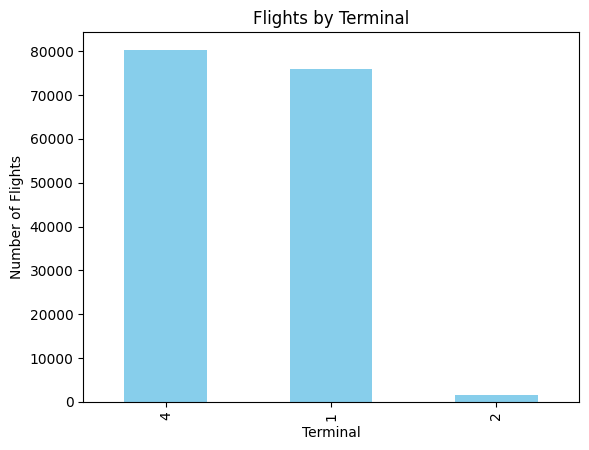

In [115]:

terminal_counts = df_clean['terminal'].value_counts()
terminal_counts.plot(kind='bar', color='skyblue')
plt.title('Flights by Terminal')
plt.xlabel('Terminal')
plt.ylabel('Number of Flights')
plt.show()

In [116]:
flight_key = [
    "airline",
    "flightnum",
    "origindate",
    "departureairport",
    "arrivalairport",
]

status_counts = (df_clean.groupby(flight_key)["status_text"].nunique()
    .reset_index(name="n_statuses"))
repeated_flights = status_counts[status_counts["n_statuses"] > 1]

print(repeated_flights.head())
print(repeated_flights.shape)


     airline flightnum origindate departureairport arrivalairport  n_statuses
4132      AC        70 2022-08-08              YUL            ALG           2
4156      AC        70 2024-06-17              YUL            ALG           2
4266      AC        71 2022-09-05              ALG            YUL           2
4279      AC        71 2024-06-17              ALG            YUL           2
4306      AC        71 2024-08-05              ALG            YUL           2
(46, 6)


In [117]:
dups = df_clean[df_clean.duplicated(subset=flight_key, keep=False)]
print(dups.head())
print(dups.shape)


           operationtime airline flightnum departureairport arrivalairport  \
2812 2022-01-25 13:52:00      EK       757              DXB            ALG   
2828 2022-01-25 17:00:00      EK       758              ALG            DXB   
2919 2022-01-25 13:55:00      EK       757              DXB            ALG   
2920 2022-01-25 17:00:00      EK       758              ALG            DXB   
2949 2022-01-27 14:00:00      EK       757              DXB            ALG   

     terminal departure/arrival origindate codecontext       status_text  \
2812        1           Arrival 2022-01-25         SCT  Scheduled_OnTime   
2828        1         Departure 2022-01-25         SCT  Scheduled_OnTime   
2919        1           Arrival 2022-01-25         ONB           Arrived   
2920        1         Departure 2022-01-25         OFB          Departed   
2949        1           Arrival 2022-01-27         SCT  Scheduled_OnTime   

            date  hour  weekday  is_weekend    route  
2812  2022-01-25   

In [118]:
status_map = {
    "SCT": "Scheduled_OnTime",   # on time
    "EAR": "Scheduled_OnTime",   # early
    "DEL": "Delayed",            # delayed

    "BST": "Boarding",           # boarding
    "BEN": "Boarding",           # final boarding
    "GCL": "Boarding",           # gate closed
    "FCL": "Boarding",           # flight closed

    "OFB": "Departed",           # departed
    "THM": "EnRoute",            # in range
    "TEN": "EnRoute",            # approach

    "LAN": "Arrived",            # landed
    "ONB": "Arrived",            # arrived / on blocks

    "DX": "Cancelled",           # canceled

    "DV": "Diverted",            # diverted
    "RT": "Diverted",            # reroute
    "GRT": "Diverted",           # ground return
}


In [119]:
df_clean['status_group'] = df_clean['codecontext'].map(status_map)
unmapped = df_clean[df_clean['status_group'].isna()]['codecontext'].unique()
print(unmapped)

[]


In [120]:
df_clean.to_csv('data/airport_data_clean.csv', index=False)

## 2.Feature Engineering

 hour: Extracted from the flight time to represent the hour of departure or arrival
  (values from 0 to 23). This helps identify peak and off-peak traffic periods

In [121]:
df_clean['hour'] = df_clean['operationtime'].dt.hour

print(df_clean['hour'].head(25))

0     16
1     18
2     12
3     13
4     10
5     11
6      8
7     10
8     12
9     14
10    13
11    15
12    14
13    16
14    16
15    18
16    22
17    20
18    18
19    19
20    20
21    17
22     8
23     9
24     8
Name: hour, dtype: int32


time_slot: Categorical feature derived from the hour to group flights into
  Morning (6–12), Afternoon (12–18), Evening (18–24), and Night (0–6),
  allowing analysis of delays by time periods.

In [122]:
df_clean['time_slot'] = pd.cut(
    df_clean['hour'],
    bins=[-1, 5, 11, 17, 21, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening', 'Late Night']
    )

print(df_clean['time_slot'].head(25))    

0      Afternoon
1        Evening
2      Afternoon
3      Afternoon
4        Morning
5        Morning
6        Morning
7        Morning
8      Afternoon
9      Afternoon
10     Afternoon
11     Afternoon
12     Afternoon
13     Afternoon
14     Afternoon
15       Evening
16    Late Night
17       Evening
18       Evening
19       Evening
20       Evening
21     Afternoon
22       Morning
23       Morning
24       Morning
Name: time_slot, dtype: category
Categories (5, object): ['Night' < 'Morning' < 'Afternoon' < 'Evening' < 'Late Night']


day_of_week: Numerical or categorical representation of the day
  (Monday to Sunday), useful for identifying weekly patterns.

In [123]:
df_clean['day_of_week'] = df_clean['operationtime'].dt.day_name()

print(df_clean['day_of_week'].head(25))

0     Wednesday
1     Wednesday
2     Wednesday
3     Wednesday
4     Wednesday
5     Wednesday
6     Wednesday
7     Wednesday
8     Wednesday
9     Wednesday
10    Wednesday
11    Wednesday
12    Wednesday
13    Wednesday
14    Wednesday
15    Wednesday
16    Wednesday
17    Wednesday
18    Wednesday
19    Wednesday
20    Wednesday
21    Wednesday
22     Thursday
23     Thursday
24     Thursday
Name: day_of_week, dtype: object


is_weekend: Boolean feature indicating whether the flight occurs on a weekend
  (Saturday or Sunday), which may affect traffic volume and delays.

In [124]:
df_clean['is_weekend'] = df_clean['day_of_week'].isin(['Saturday', 'Friday'])

print(df_clean['is_weekend'].head())


0    False
1    False
2    False
3    False
4    False
Name: is_weekend, dtype: bool


In [125]:
df_clean['month'] = df_clean['operationtime'].dt.month

print(df_clean['month'].head(25))

0     12
1     12
2     12
3     12
4     12
5     12
6     12
7     12
8     12
9     12
10    12
11    12
12    12
13    12
14    12
15    12
16    12
17    12
18    12
19    12
20    12
21    12
22    12
23    12
24    12
Name: month, dtype: int32


season: Categorical feature grouping months into seasons
  (Winter, Spring, Summer, Fall) to capture weather and holiday effects.


In [126]:
df_clean['season'] = pd.cut(
    df_clean['month'],
    bins=[0, 3, 6, 9, 12],
    labels=['Winter', 'Spring', 'Summer', 'Autumn'])


print(df_clean['season'].head(25))    

0     Autumn
1     Autumn
2     Autumn
3     Autumn
4     Autumn
5     Autumn
6     Autumn
7     Autumn
8     Autumn
9     Autumn
10    Autumn
11    Autumn
12    Autumn
13    Autumn
14    Autumn
15    Autumn
16    Autumn
17    Autumn
18    Autumn
19    Autumn
20    Autumn
21    Autumn
22    Autumn
23    Autumn
24    Autumn
Name: season, dtype: category
Categories (4, object): ['Winter' < 'Spring' < 'Summer' < 'Autumn']


 week_of_year: Indicates the week number within the year, useful for detecting
  periodic trends and peak travel weeks.

In [127]:
df_clean['week_of_year'] = df_clean['operationtime'].dt.isocalendar().week

print(df_clean['week_of_year'].head(25))

0     52
1     52
2     52
3     52
4     52
5     52
6     52
7     52
8     52
9     52
10    52
11    52
12    52
13    52
14    52
15    52
16    52
17    52
18    52
19    52
20    52
21    52
22    52
23    52
24    52
Name: week_of_year, dtype: UInt32


is_domestic: Boolean feature indicating whether the flight destination
  is within Algeria.

In [128]:
df_clean['is_domestic'] = df_clean['departureairport'] .str[:2] == df_clean['arrivalairport'].str[:2]

print(df_clean['is_domestic'].head())

0    False
1    False
2    False
3    False
4    False
Name: is_domestic, dtype: bool


is_international: Boolean feature indicating whether the destination
  is outside Algeria.

In [129]:
df_clean['is_international'] = ~df_clean['is_domestic']

print(df_clean['is_international'].head())

0    True
1    True
2    True
3    True
4    True
Name: is_international, dtype: bool


route_type: High-level categorical feature classifying flights into
  Domestic, European, Middle East, African, or Long-haul routes, enabling
  comparison of delay patterns across different travel regions.

In [130]:
airport_country = {
    'CDG': 'FR',
    'ORY': 'FR',
    'IST': 'TR',
    'ORN': 'DZ',
    'JFK': 'US',
    'YUL': 'CA'
}

df_clean['departure_country'] = df_clean['departureairport'].map(airport_country)
df_clean['arrival_country']   = df_clean['arrivalairport'].map(airport_country)
print(df_clean[['departureairport', 'departure_country', 'arrivalairport', 'arrival_country']].head(10))



  departureairport departure_country arrivalairport arrival_country
0              ORY                FR            ALG             NaN
1              ALG               NaN            BCN             NaN
2              FRA               NaN            ALG             NaN
3              ALG               NaN            FRA             NaN
4              CDG                FR            ALG             NaN
5              ALG               NaN            CDG              FR
6              YUL                CA            ALG             NaN
7              ALG               NaN            TMR             NaN
8              CDG                FR            ALG             NaN
9              ALG               NaN            CDG              FR


In [135]:
status_map_encoded = {
    # On time
    "SCT": "OnTime",
    "EAR": "OnTime",
    "BST": "OnTime",
    "BEN": "OnTime",
    "GCL": "OnTime",
    "FCL": "OnTime",
    "OFB": "OnTime",
    "THM": "OnTime",
    "TEN": "OnTime",
    "LAN": "OnTime",
    "ONB": "OnTime",

    # Delayed
    "DEL": "Delayed",
    "DV": "Delayed",
    "RT": "Delayed",
    "GRT": "Delayed",

    # Cancelled
    "DX": "Cancelled"
}


In [139]:
df_clean['flight_status'] = df_clean['codecontext'].map(status_map_encoded)

print(df_clean[['codecontext', 'flight_status']].head(10))
df_clean.head()

  codecontext flight_status
0         ONB        OnTime
1         OFB        OnTime
2         ONB        OnTime
3         OFB        OnTime
4         ONB        OnTime
5         OFB        OnTime
6         ONB        OnTime
7         OFB        OnTime
8         ONB        OnTime
9         OFB        OnTime


,operationtime,airline,flightnum,departureairport,arrivalairport,terminal,departure/arrival,origindate,codecontext,status_text,...,time_slot,day_of_week,month,season,week_of_year,is_domestic,is_international,departure_country,arrival_country,flight_status
0,2021-12-29 16:49:00,AH,1011,ORY,ALG,4,Arrival,2021-12-29,ONB,Arrived,...,Afternoon,Wednesday,12,Autumn,52,False,True,FR,NaN,OnTime
1,2021-12-29 18:30:00,AH,2014,ALG,BCN,4,Departure,2021-12-29,OFB,Departed,...,Evening,Wednesday,12,Autumn,52,False,True,NaN,NaN,OnTime
2,2021-12-29 12:09:00,LH,1316,FRA,ALG,4,Arrival,2021-12-29,ONB,Arrived,...,Afternoon,Wednesday,12,Autumn,52,False,True,NaN,NaN,OnTime
3,2021-12-29 13:25:00,LH,1317,ALG,FRA,4,Departure,2021-12-29,OFB,Departed,...,Afternoon,Wednesday,12,Autumn,52,False,True,NaN,NaN,OnTime
4,2021-12-29 10:03:00,5O,1051,CDG,ALG,4,Arrival,2021-12-29,ONB,Arrived,...,Morning,Wednesday,12,Autumn,52,False,True,FR,NaN,OnTime


In [141]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157718 entries, 0 to 157717
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   operationtime      157718 non-null  datetime64[ns]
 1   airline            157718 non-null  object        
 2   flightnum          157718 non-null  object        
 3   departureairport   157718 non-null  object        
 4   arrivalairport     157718 non-null  object        
 5   terminal           157718 non-null  object        
 6   departure/arrival  157718 non-null  object        
 7   origindate         157718 non-null  datetime64[ns]
 8   codecontext        157718 non-null  object        
 9   status_text        157718 non-null  object        
 10  date               157718 non-null  object        
 11  hour               157718 non-null  int32         
 12  weekday            157718 non-null  int32         
 13  is_weekend         157718 non-null  bool    

In [ ]:
cluster_df = df_clean[[ 'airline','route', 'is_domestic', 'is_international', 'flight_status']].copy()

cluster_df ['airline_route']= cluster_df['airline'] + "_" + cluster_df['route']

flight_counts = cluster_df.groupby('airline_route').size().reset_index(name='total_flights')
valid_combinations = flight_counts[flight_counts['total_flights'] >= 30]

print('Total airline-route combinations:', cluster_df.shape[0])




Total airline-route combinations: 157718
['airline_route', 'flight_count']


In [154]:
cluster_df_filtered = cluster_df[cluster_df['airline_route'].isin(valid_combinations['airline_route'])]

status_counts = cluster_df_filtered.groupby(['airline_route', 'flight_status']).size().unstack(fill_value=0)

print(status_counts.columns.tolist())



['Cancelled', 'Delayed', 'OnTime']


In [ ]:

clustering_df = cluster_df_filtered.groupby(['airline', 'route', 'airline_route']).agg({
    'is_domestic': 'first',  
    'flight_status': 'count'  
}).reset_index()

clustering_df.rename(columns={'flight_status': 'total_flights'}, inplace=True)
clustering_df =  clustering_df.merge(status_counts, on='airline_route', how='left')
total_flights = clustering_df['total_flights']
clustering_df['ontime_rate'] = (clustering_df['OnTime'] / total_flights) * 100
clustering_df['delayed_rate'] = (clustering_df['Delayed'] / total_flights) * 100
clustering_df['cancelled_rate'] = (clustering_df['Cancelled'] / total_flights) * 100

clustering_df.head()

print(clustering_df[['ontime_rate', 'delayed_rate', 'cancelled_rate']].describe())



,airline,route,airline_route,is_domestic,total_flights,Cancelled,Delayed,OnTime,ontime_rate,delayed_rate,cancelled_rate
0,5O,ALG-CDG,5O_ALG-CDG,False,1208,32,71,1105,91.473510,5.877483,2.649007
1,5O,ALG-LIL,5O_ALG-LIL,False,273,3,9,261,95.604396,3.296703,1.098901
2,5O,ALG-LYS,5O_ALG-LYS,False,454,7,7,440,96.916300,1.541850,1.541850
3,5O,ALG-MLH,5O_ALG-MLH,False,89,1,3,85,95.505618,3.370787,1.123596
4,5O,CDG-ALG,5O_CDG-ALG,False,1196,27,14,1155,96.571906,1.170569,2.257525
